# 05 PCA Regime Concentration

Does stress concentrate portfolio risk onto fewer independent directions? For each
universe we eigendecompose the **raw regime-conditional correlation matrix** (calm vs
stress) and summarise concentration with two measures:

- **PC1 share** $=\lambda_1/N$ — the fraction of total variance on the leading component.
- **Effective number of bets** $N_{\mathrm{eff}} = N^2/\sum_k \lambda_k^2$ — the participation ratio of the eigenvalue spectrum ($N$ = fully diversified, $1$ = single factor).

A universe is **more concentrated in stress** when PC1 share rises *and* $N_{\mathrm{eff}}$
falls. All three universes are compared on the common balanced window; Panel B is also
checked on its full 2003-onward sample. Every table (CSV) and figure (PNG) is written to
`outputs/05_pca/`, from where the report picks them up.

## 1. Setup

In [1]:
# =====================================================================
# Notebook 05 -- PCA Regime Concentration: setup
#
# Reuses the project's PCA helpers (src/analysis/pca_concentration.py) so every
# number matches the pipeline, and writes all report figures (PNG) and tables
# (CSV) to outputs/05_pca/. Uses the repository-anchored settings paths.
# =====================================================================
from __future__ import annotations

from pathlib import Path
import sys

import duckdb
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import pandas as pd
from IPython.display import display
from mizani.labels import label_percent
from plotnine import *


def find_project_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "src").is_dir() and (path / "data").is_dir():
            return path
    raise RuntimeError("Could not find project root containing src/ and data/.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import settings
from analysis.pca_concentration import (
    build_universe_outputs,
    common_complete_case_dates,
    load_labeled_return_table,
    prepare_labeled_returns,
    write_pca_outputs,
)
from features.regime_assignment import ETF_TABLE

pd.set_option("display.max_columns", 80)

## 2. Settings

In [2]:
REBUILD_PCA_TABLES = True
WRITE_TO_DATABASE = False
EXPORT_OUTPUTS = True

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "05_pca"
SCHEMA_DIR = PROJECT_ROOT / "sql" / "schema"
PLOT_DPI = 150

PCA_UNIVERSES = (
    ("panel_a_cross_asset", settings.PANEL_A),
    ("panel_b_international_equity", settings.PANEL_B),
    ("etf_assets", settings.ETF_ASSETS),
)

UNIVERSE_LABELS = {
    "panel_a_cross_asset": "Panel A: cross-asset",
    "panel_b_international_equity": "Panel B: international equity",
    "etf_assets": "Combined ETF assets",
}

REGIME_LABELS = {"full": "Full sample", "calm": "Calm", "stress": "Stress"}
REGIME_COLORS = {"calm": "#4C78A8", "stress": "#F58518"}
PCA_SCHEMA_FILES = [
    "08_pca_regime_concentration_eigenvalues.sql",
    "08_pca_regime_concentration_summary.sql",
    "08_pca_regime_concentration_comparison.sql",
]

print(f"Database: {settings.DB_PATH}")
print(f"Outputs : {OUTPUT_DIR}")

Database: C:\Users\salio\OneDrive\Desktop\University\TUM\Data Science in Finance\DataScienceSeminar\data\lsr.duckdb
Outputs : C:\Users\salio\OneDrive\Desktop\University\TUM\Data Science in Finance\DataScienceSeminar\outputs\05_pca


## 3. Load Data

In [3]:
settings.require_data_dir()
con = duckdb.connect(str(settings.DB_PATH))

raw_labeled = load_labeled_return_table(con, ETF_TABLE)
raw_labeled["ms_stress"] = raw_labeled["ms_stress"].astype("Int64")

overview = pd.DataFrame(
    [
        {"metric": "input table", "value": ETF_TABLE},
        {"metric": "rows", "value": len(raw_labeled)},
        {"metric": "first date", "value": raw_labeled["date"].min()},
        {"metric": "last date", "value": raw_labeled["date"].max()},
        {"metric": "stress label", "value": "primary Markov P(stress) >= 0.50"},
    ]
)
display(overview)


,metric,value
0,input table,etf_returns_monthly_markov_labeled
1,rows,6518
2,first date,2000-02-01 00:00:00
3,last date,2025-12-30 00:00:00
4,stress label,primary Markov P(stress) >= 0.50


## 4. Compute PCA Outputs

For each universe we eigendecompose the calm and stress correlation matrices on the
**common balanced window** (the dates where all combined-universe assets are observed, so
every panel shares the same trading days and calm/stress mix). We then record the PC1
share, the top-3/top-5 shares, and the effective number of bets per regime, and flag a
universe as *more concentrated in stress* when PC1 rises and the effective number of bets
falls. An assertion enforces that the flag means exactly that. Panel B is additionally
re-run on its full 2003-onward sample as a robustness check, since it is the only universe
the common-window restriction shortens.

In [4]:
# Common balanced window: the dates where ALL combined-universe assets are
# observed (HYG's April-2007 inception binds it). Restricting every panel to this
# window puts Panel A, Panel B and the combined universe on the same trading days
# and the same calm/stress mix, so the cross-panel comparison is apples-to-apples.
# Panel A and the combined universe already sit on this window; only Panel B (no
# HYG, no commodities) is shortened. Its full-sample result is kept for robustness.
COMMON_DATES = common_complete_case_dates(raw_labeled, list(settings.ETF_ASSETS))
print(
    f"common window: {COMMON_DATES.min().date()} -> {COMMON_DATES.max().date()} "
    f"({len(COMMON_DATES):,} trading days)"
)


def build_all_pca_outputs(raw_data: pd.DataFrame, *, restrict_dates=COMMON_DATES):
    eigenvalue_frames = []
    summary_frames = []
    comparison_frames = []
    sample_rows = []

    for universe, requested_columns in PCA_UNIVERSES:
        data, return_columns = prepare_labeled_returns(
            raw_data,
            list(requested_columns),
            source_name=f"{ETF_TABLE}/{universe}",
            restrict_dates=restrict_dates,
        )
        eigenvalues_u, summary_u, comparison_u = build_universe_outputs(
            universe, data, return_columns
        )

        eigenvalue_frames.append(eigenvalues_u)
        summary_frames.append(summary_u)
        comparison_frames.append(comparison_u)
        sample_rows.append(
            {
                "universe": universe,
                "label": UNIVERSE_LABELS[universe],
                "assets": len(return_columns),
                "complete_case_days": len(data),
                "calm_days": int((data["ms_stress"] == 0).sum()),
                "stress_days": int((data["ms_stress"] == 1).sum()),
                "stress_share": float(data["ms_stress"].mean()),
            }
        )

    return (
        pd.concat(eigenvalue_frames, ignore_index=True),
        pd.concat(summary_frames, ignore_index=True),
        pd.concat(comparison_frames, ignore_index=True),
        pd.DataFrame(sample_rows),
    )


eigenvalues, summary, comparison, sample_summary = build_all_pca_outputs(raw_labeled)

expected = (
    (comparison["stress_minus_calm_pc1_share"] > 0)
    & (comparison["stress_minus_calm_effective_bets"] < 0)
)
if not expected.equals(comparison["more_concentrated_in_stress"]):
    raise AssertionError("Concentration flag must mean PC1-up and effective-bets-down.")

display(sample_summary.style.format({"stress_share": "{:.1%}"}))


# --- Robustness: Panel B on the common window vs its full sample ---------------
# Panel B is the only universe the common-window restriction changes. We report
# both so the appendix can show the concentration verdict holds either way.
def panel_b_window_row(window_label: str, restrict_dates) -> dict:
    data, cols = prepare_labeled_returns(
        raw_labeled,
        list(settings.PANEL_B),
        source_name="panel_b_window_check",
        restrict_dates=restrict_dates,
    )
    _, _, cmp = build_universe_outputs("panel_b_international_equity", data, cols)
    row = cmp.iloc[0].to_dict()
    row = {
        "window": window_label,
        "observations": len(data),
        "calm_days": int((data["ms_stress"] == 0).sum()),
        "stress_days": int((data["ms_stress"] == 1).sum()),
        "stress_share": float(data["ms_stress"].mean()),
        **{k: v for k, v in row.items() if k != "universe"},
    }
    return row


panel_b_window_robustness = pd.DataFrame(
    [
        panel_b_window_row("common (2007-04 onward)", COMMON_DATES),
        panel_b_window_row("full sample (2003 onward)", None),
    ]
)
display(
    panel_b_window_robustness.style.format(
        {
            "stress_share": "{:.1%}",
            "calm_pc1_share": "{:.2%}",
            "stress_pc1_share": "{:.2%}",
            "stress_minus_calm_pc1_share": "{:+.2%}",
            "calm_effective_bets": "{:.2f}",
            "stress_effective_bets": "{:.2f}",
            "stress_minus_calm_effective_bets": "{:+.2f}",
        }
    )
)


common window: 2007-04-12 -> 2025-12-30 (4,711 trading days)


,universe,label,assets,complete_case_days,calm_days,stress_days,stress_share
0,panel_a_cross_asset,Panel A: cross-asset,9,4711,2443,2268,48.1%
1,panel_b_international_equity,Panel B: international equity,6,4711,2443,2268,48.1%
2,etf_assets,Combined ETF assets,14,4711,2443,2268,48.1%


,window,observations,calm_days,stress_days,stress_share,calm_pc1_share,stress_pc1_share,stress_minus_calm_pc1_share,calm_effective_bets,stress_effective_bets,stress_minus_calm_effective_bets,more_concentrated_in_stress
0,common (2007-04 onward),4711,2443,2268,48.1%,78.73%,88.86%,+10.14%,1.58,1.26,-0.32,True
1,full sample (2003 onward),5715,3436,2279,39.9%,77.88%,88.80%,+10.92%,1.62,1.26,-0.35,True


## 5. Main Tables

In [5]:
summary_display = summary.copy()
summary_display.insert(1, "label", summary_display["universe"].map(UNIVERSE_LABELS))
summary_display["regime"] = summary_display["regime"].map(REGIME_LABELS)

interpretation = comparison.merge(
    sample_summary[["universe", "label", "assets", "calm_days", "stress_days"]],
    on="universe",
    how="left",
)
interpretation["supports_concentration_story"] = (
    (interpretation["stress_minus_calm_pc1_share"] > 0)
    & (interpretation["stress_minus_calm_effective_bets"] < 0)
)
interpretation = interpretation[
    [
        "universe",
        "label",
        "assets",
        "calm_days",
        "stress_days",
        "calm_pc1_share",
        "stress_pc1_share",
        "stress_minus_calm_pc1_share",
        "calm_effective_bets",
        "stress_effective_bets",
        "stress_minus_calm_effective_bets",
        "supports_concentration_story",
    ]
]

percent_cols = ["stress_share", "pc1_share", "pc2_share", "top_3_share", "top_5_share"]
comparison_format = {
    "calm_pc1_share": "{:.2%}",
    "stress_pc1_share": "{:.2%}",
    "stress_minus_calm_pc1_share": "{:+.2%}",
    "calm_effective_bets": "{:.2f}",
    "stress_effective_bets": "{:.2f}",
    "stress_minus_calm_effective_bets": "{:+.2f}",
}

display(
    summary_display.style.format(
        {**{col: "{:.2%}" for col in percent_cols}, "effective_bets": "{:.2f}"}
    )
)
display(interpretation.style.format(comparison_format))


,universe,label,regime,observations,assets,stress_share,pc1_share,pc2_share,top_3_share,top_5_share,effective_bets
0,panel_a_cross_asset,Panel A: cross-asset,Full sample,4711,9,48.14%,35.55%,24.93%,75.79%,89.35%,4.44
1,panel_a_cross_asset,Panel A: cross-asset,Calm,2443,9,48.14%,30.85%,29.04%,76.75%,90.44%,4.52
2,panel_a_cross_asset,Panel A: cross-asset,Stress,2268,9,48.14%,37.39%,23.86%,75.81%,89.35%,4.33
3,panel_b_international_equity,Panel B: international equity,Full sample,4711,6,48.14%,86.26%,5.07%,94.85%,99.71%,1.33
4,panel_b_international_equity,Panel B: international equity,Calm,2443,6,48.14%,78.73%,7.73%,92.17%,99.64%,1.58
5,panel_b_international_equity,Panel B: international equity,Stress,2268,6,48.14%,88.86%,3.92%,95.66%,99.73%,1.26
6,etf_assets,Combined ETF assets,Full sample,4711,14,48.14%,49.41%,16.44%,76.75%,85.87%,3.44
7,etf_assets,Combined ETF assets,Calm,2443,14,48.14%,42.68%,19.30%,74.15%,84.25%,4.11
8,etf_assets,Combined ETF assets,Stress,2268,14,48.14%,51.86%,15.72%,77.94%,87.12%,3.21


,universe,label,assets,calm_days,stress_days,calm_pc1_share,stress_pc1_share,stress_minus_calm_pc1_share,calm_effective_bets,stress_effective_bets,stress_minus_calm_effective_bets,supports_concentration_story
0,panel_a_cross_asset,Panel A: cross-asset,9,2443,2268,30.85%,37.39%,+6.54%,4.52,4.33,-0.20,True
1,panel_b_international_equity,Panel B: international equity,6,2443,2268,78.73%,88.86%,+10.14%,1.58,1.26,-0.32,True
2,etf_assets,Combined ETF assets,14,2443,2268,42.68%,51.86%,+9.19%,4.11,3.21,-0.90,True


## 6. Plots

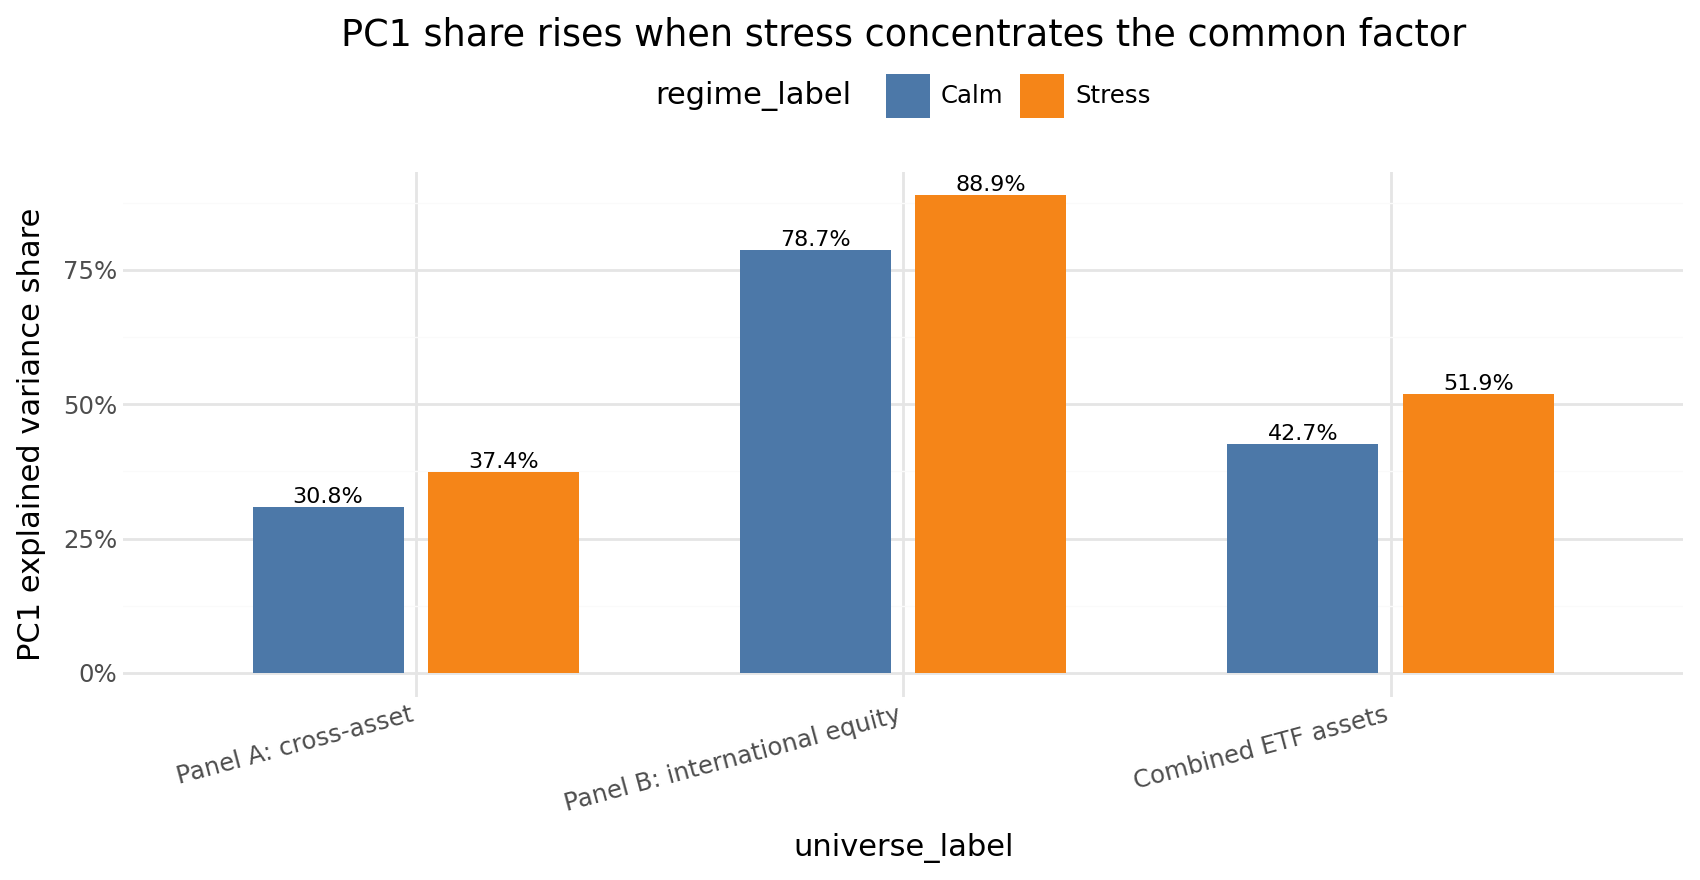

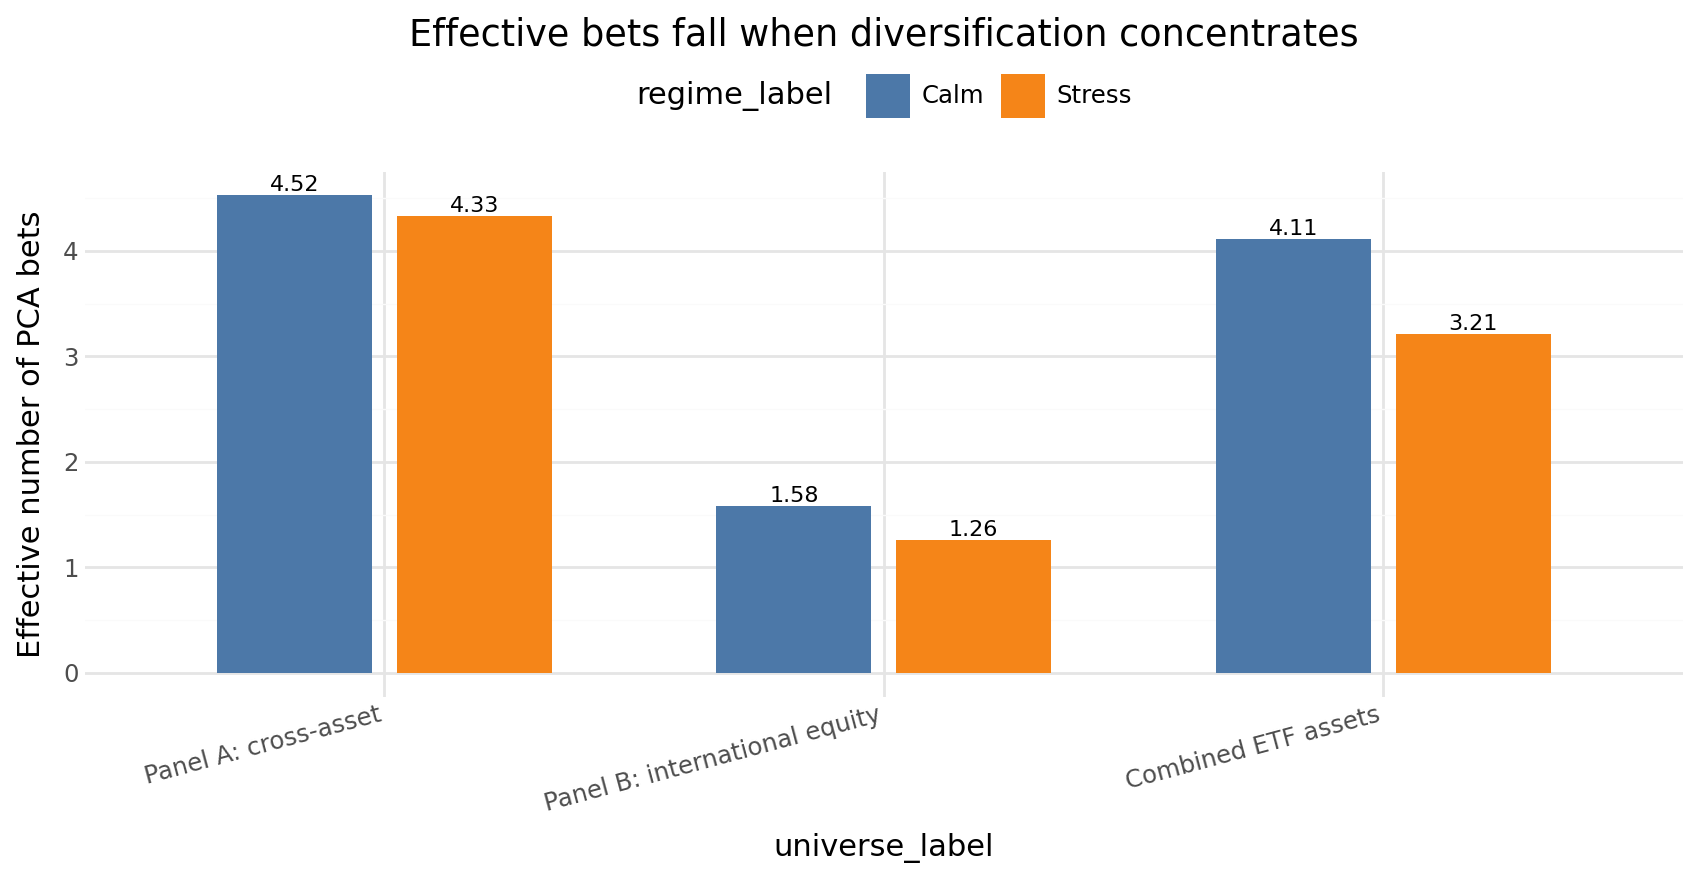

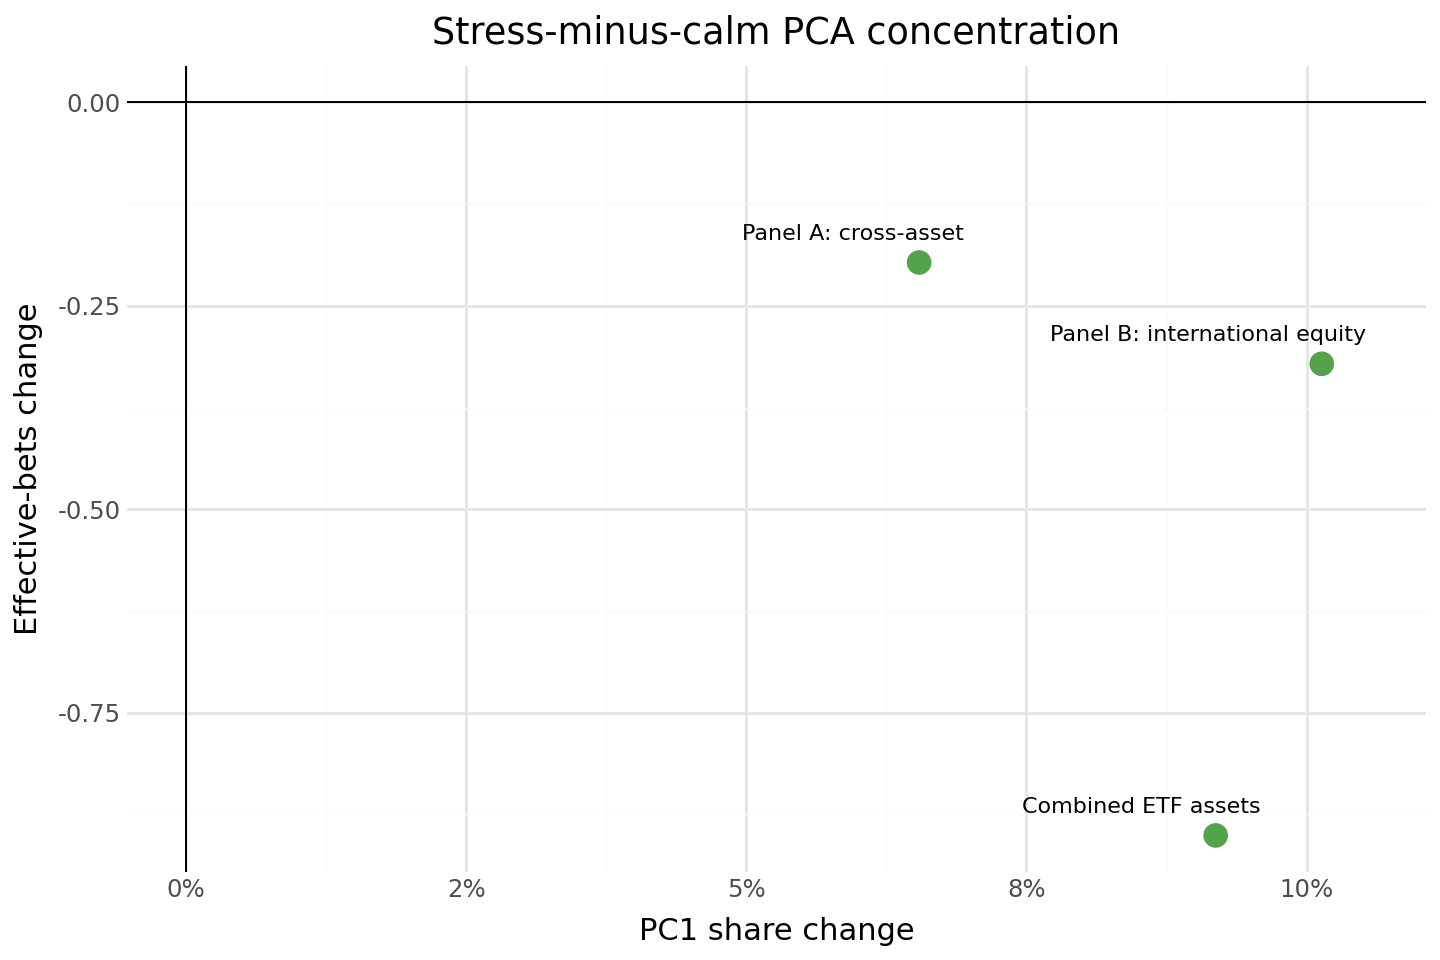

In [6]:
if EXPORT_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

figure_exports = []


def save_plot(plot, filename: str, *, width: float = 8.5, height: float = 4.4) -> None:
    if EXPORT_OUTPUTS:
        path = OUTPUT_DIR / filename
        plot.save(path, width=width, height=height, dpi=PLOT_DPI, verbose=False)
        figure_exports.append({"figure": filename, "path": str(path)})


def metric_plot_data(metric: str, label_fn) -> pd.DataFrame:
    frame = summary.loc[summary["regime"].isin(["calm", "stress"]), ["universe", "regime", metric]].copy()
    frame["universe_label"] = pd.Categorical(
        frame["universe"].map(UNIVERSE_LABELS),
        categories=[UNIVERSE_LABELS[universe] for universe, _ in PCA_UNIVERSES],
        ordered=True,
    )
    frame["regime_label"] = pd.Categorical(
        frame["regime"].map(REGIME_LABELS),
        categories=["Calm", "Stress"],
        ordered=True,
    )
    frame["value"] = frame[metric]
    frame["value_label"] = frame["value"].map(label_fn)
    return frame


def plot_regime_bars(metric: str, title: str, ylabel: str, filename: str, label_fn, y_scale):
    plot_data = metric_plot_data(metric, label_fn)
    plot = (
        ggplot(plot_data, aes(x="universe_label", y="value", fill="regime_label"))
        + geom_col(position=position_dodge(width=0.72), width=0.62)
        + geom_text(
            aes(label="value_label"),
            position=position_dodge(width=0.72),
            va="bottom",
            size=8,
        )
        + scale_fill_manual(values={"Calm": REGIME_COLORS["calm"], "Stress": REGIME_COLORS["stress"]})
        + y_scale
        + labs(title=title, x=None, y=ylabel, fill=None)
        + theme_minimal()
        + theme(
            axis_text_x=element_text(rotation=15, ha="right"),
            legend_position="top",
            figure_size=(8.5, 4.4),
        )
    )
    save_plot(plot, filename)
    display(plot)


plot_regime_bars(
    "pc1_share",
    "PC1 share rises when stress concentrates the common factor",
    "PC1 explained variance share",
    "pc1_share_calm_vs_stress.png",
    lambda value: f"{value:.1%}",
    scale_y_continuous(labels=label_percent(accuracy=1)),
)
plot_regime_bars(
    "effective_bets",
    "Effective bets fall when diversification concentrates",
    "Effective number of PCA bets",
    "effective_bets_calm_vs_stress.png",
    lambda value: f"{value:.2f}",
    scale_y_continuous(),
)

delta_plot_data = comparison.copy()
delta_plot_data["label"] = delta_plot_data["universe"].map(UNIVERSE_LABELS)

delta_plot = (
    ggplot(
        delta_plot_data,
        aes(
            x="stress_minus_calm_pc1_share",
            y="stress_minus_calm_effective_bets",
            label="label",
        ),
    )
    + geom_vline(xintercept=0, color="black", size=0.4)
    + geom_hline(yintercept=0, color="black", size=0.4)
    + geom_point(color="#54A24B", size=4)
    + geom_text(nudge_x=0.004, nudge_y=0.035, ha="right", size=8)
    + scale_x_continuous(labels=label_percent(accuracy=1))
    + labs(
        title="Stress-minus-calm PCA concentration",
        x="PC1 share change",
        y="Effective-bets change",
    )
    + theme_minimal()
    + theme(figure_size=(7.2, 4.8))
)
save_plot(delta_plot, "concentration_delta_quadrant.png", width=7.2, height=4.8)
display(delta_plot)


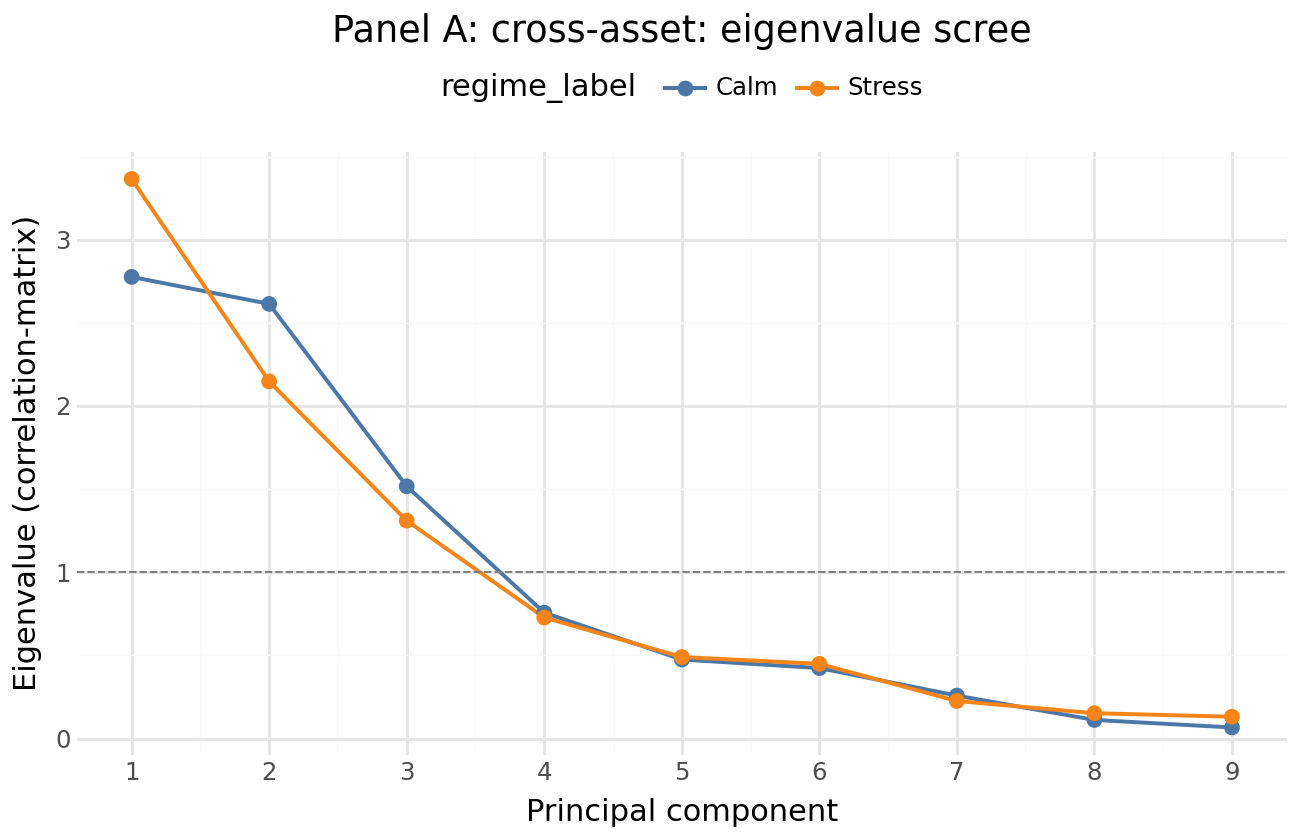

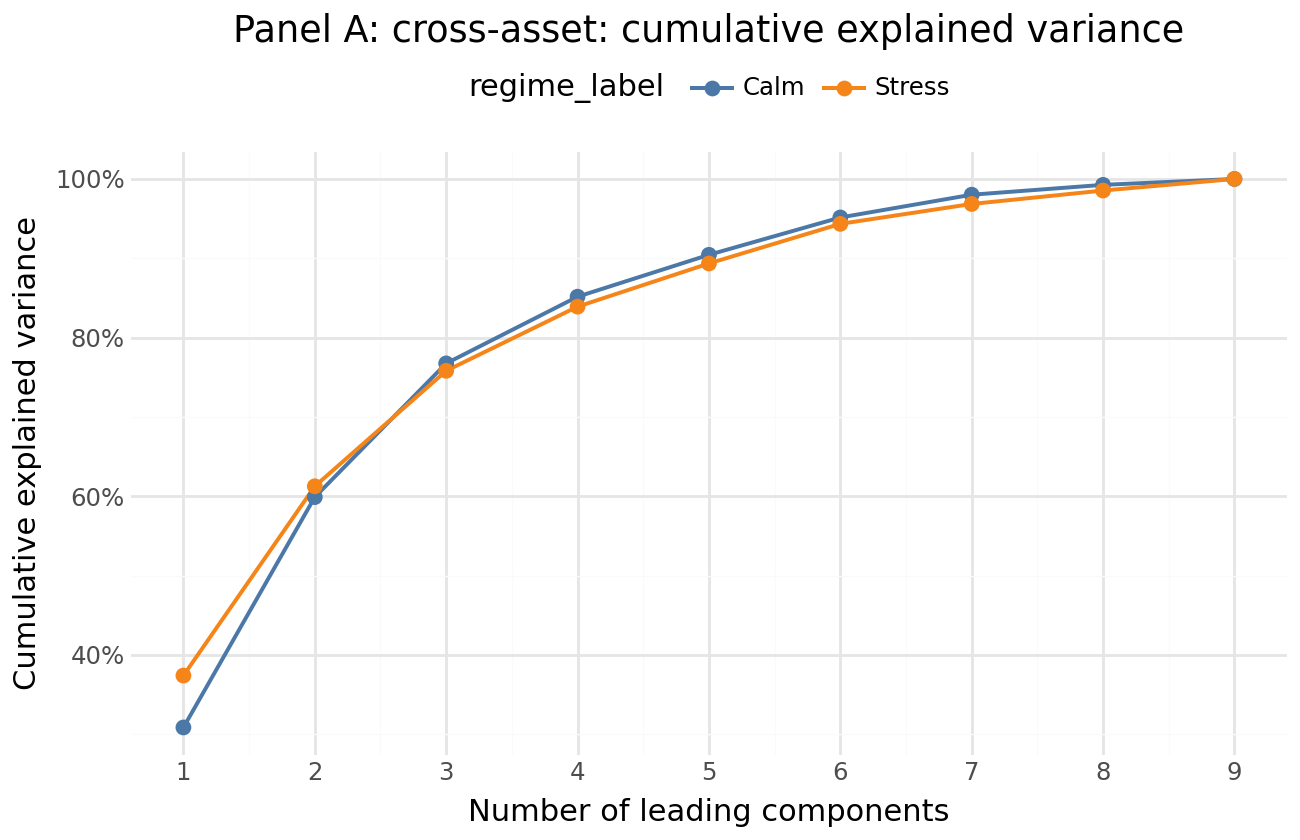

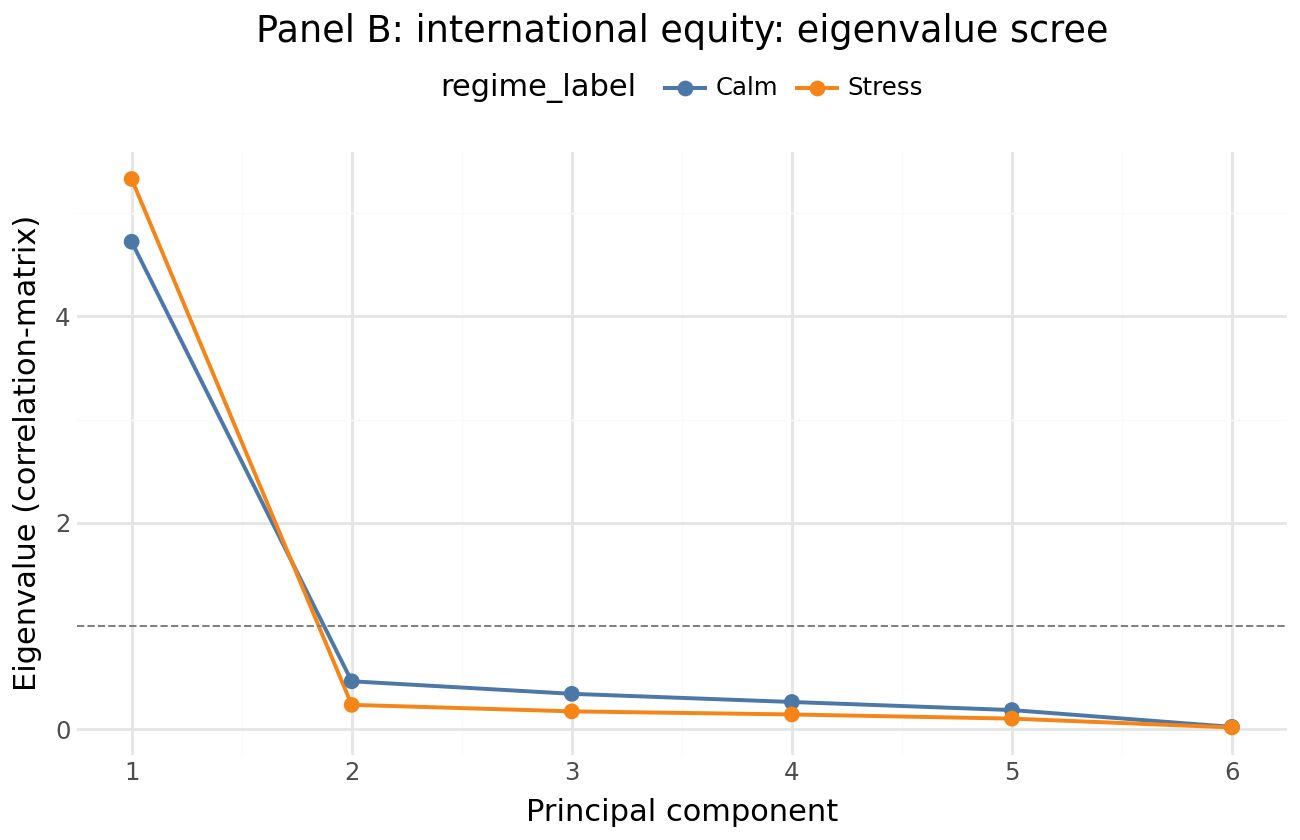

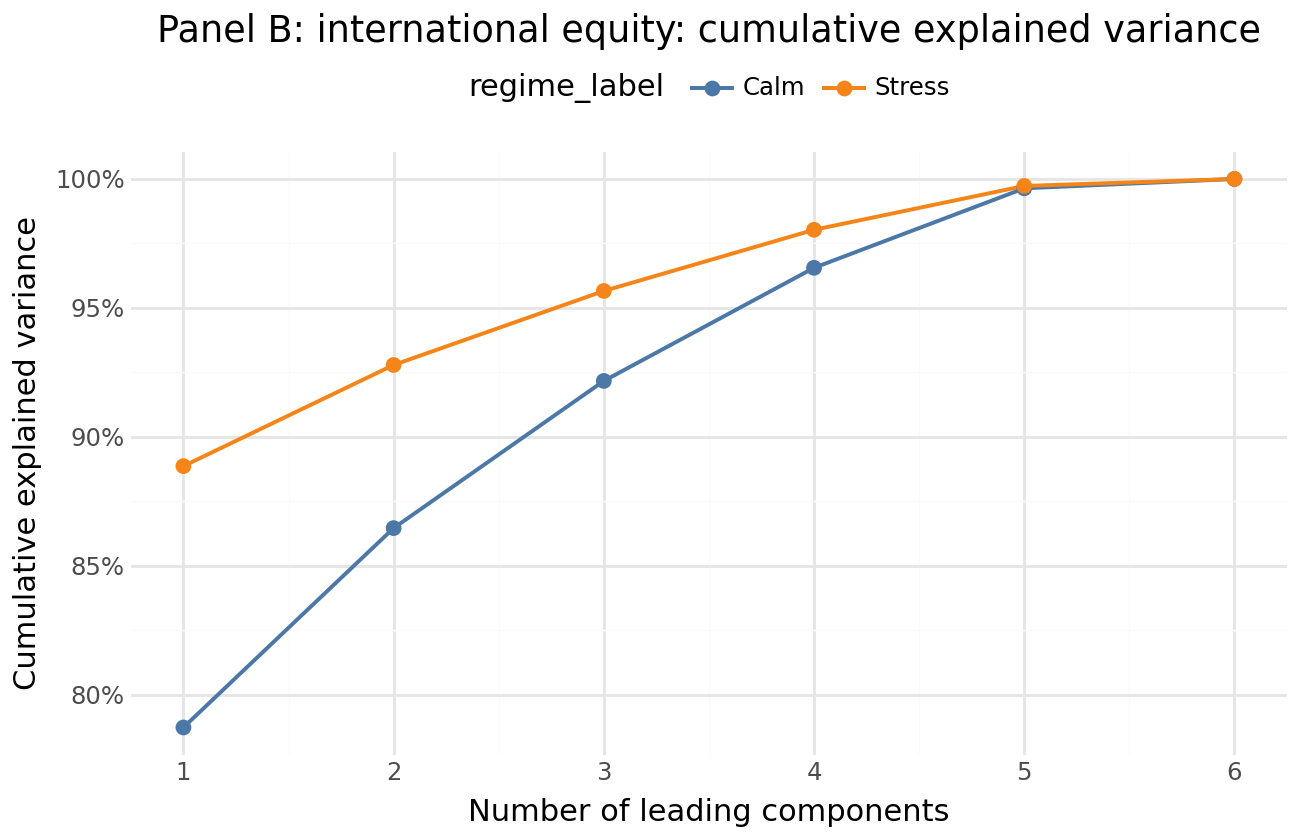

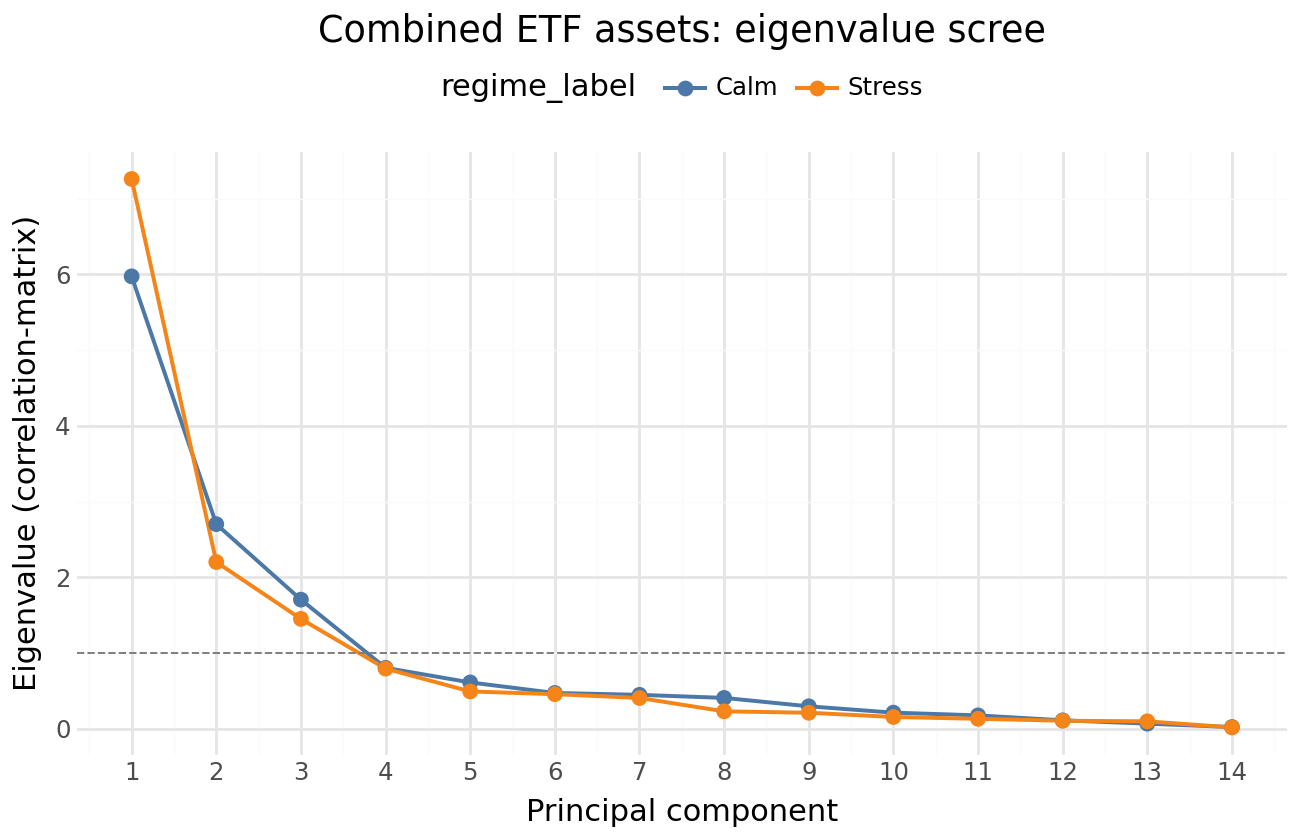

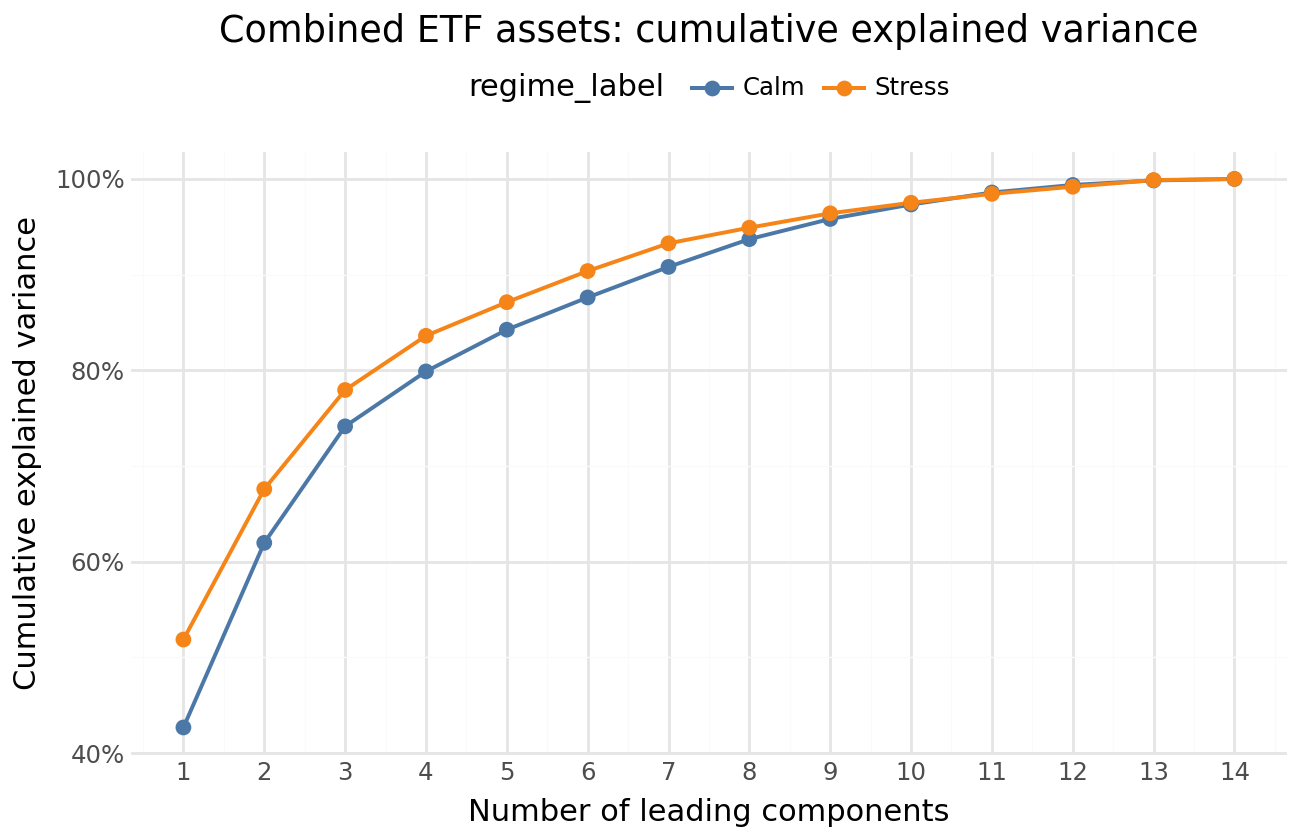

In [7]:
# Scree and cumulative-explained-variance curves by regime (appendix figures).
scree_data = eigenvalues[eigenvalues["regime"].isin(["calm", "stress"])].copy()
scree_data["regime_label"] = pd.Categorical(
    scree_data["regime"].map(REGIME_LABELS), categories=["Calm", "Stress"], ordered=True
)
scree_colors = {"Calm": REGIME_COLORS["calm"], "Stress": REGIME_COLORS["stress"]}

for universe, _ in PCA_UNIVERSES:
    sub = scree_data[scree_data["universe"] == universe]
    breaks = list(range(1, int(sub["component"].max()) + 1))

    scree = (
        ggplot(sub, aes(x="component", y="eigenvalue", color="regime_label"))
        + geom_line(size=0.8)
        + geom_point(size=2.2)
        + geom_hline(yintercept=1.0, linetype="dashed", color="grey", size=0.4)
        + scale_color_manual(values=scree_colors)
        + scale_x_continuous(breaks=breaks)
        + labs(
            title=f"{UNIVERSE_LABELS[universe]}: eigenvalue scree",
            x="Principal component",
            y="Eigenvalue (correlation-matrix)",
            color=None,
        )
        + theme_minimal()
        + theme(legend_position="top", figure_size=(6.5, 4.2))
    )
    save_plot(scree, f"{universe}_scree.png", width=6.5, height=4.2)
    display(scree)

    cumulative = (
        ggplot(sub, aes(x="component", y="cumulative_explained_variance_share", color="regime_label"))
        + geom_line(size=0.8)
        + geom_point(size=2.2)
        + scale_color_manual(values=scree_colors)
        + scale_x_continuous(breaks=breaks)
        + scale_y_continuous(labels=label_percent(accuracy=1))
        + labs(
            title=f"{UNIVERSE_LABELS[universe]}: cumulative explained variance",
            x="Number of leading components",
            y="Cumulative explained variance",
            color=None,
        )
        + theme_minimal()
        + theme(legend_position="top", figure_size=(6.5, 4.2))
    )
    save_plot(cumulative, f"{universe}_cumulative_explained_variance.png", width=6.5, height=4.2)
    display(cumulative)


## 7. Save Outputs

In [8]:
if WRITE_TO_DATABASE:
    if REBUILD_PCA_TABLES:
        for schema_file in PCA_SCHEMA_FILES:
            con.execute((SCHEMA_DIR / schema_file).read_text())
    write_pca_outputs(con, eigenvalues, summary, comparison)

if EXPORT_OUTPUTS:
    table_exports = {
        "pca_regime_concentration_eigenvalues.csv": eigenvalues,
        "pca_regime_concentration_summary.csv": summary,
        "pca_regime_concentration_comparison.csv": comparison,
        "pca_sample_summary.csv": sample_summary,
        "pca_interpretation_table.csv": interpretation,
        "pca_panel_b_window_robustness.csv": panel_b_window_robustness,
    }
    exported_tables = []
    for filename, frame in table_exports.items():
        path = OUTPUT_DIR / filename
        frame.to_csv(path, index=False)
        exported_tables.append({"table": filename, "rows": len(frame), "path": str(path)})
    display(pd.DataFrame(exported_tables))
    display(pd.DataFrame(figure_exports))


,table,rows,path
0,pca_regime_concentration_eigenvalues.csv,87,C:\Users\salio\OneDrive\Desktop\University\TUM...
1,pca_regime_concentration_summary.csv,9,C:\Users\salio\OneDrive\Desktop\University\TUM...
2,pca_regime_concentration_comparison.csv,3,C:\Users\salio\OneDrive\Desktop\University\TUM...
3,pca_sample_summary.csv,3,C:\Users\salio\OneDrive\Desktop\University\TUM...
4,pca_interpretation_table.csv,3,C:\Users\salio\OneDrive\Desktop\University\TUM...
5,pca_panel_b_window_robustness.csv,2,C:\Users\salio\OneDrive\Desktop\University\TUM...


,figure,path
0,pc1_share_calm_vs_stress.png,C:\Users\salio\OneDrive\Desktop\University\TUM...
1,effective_bets_calm_vs_stress.png,C:\Users\salio\OneDrive\Desktop\University\TUM...
2,concentration_delta_quadrant.png,C:\Users\salio\OneDrive\Desktop\University\TUM...
3,panel_a_cross_asset_scree.png,C:\Users\salio\OneDrive\Desktop\University\TUM...
4,panel_a_cross_asset_cumulative_explained_varia...,C:\Users\salio\OneDrive\Desktop\University\TUM...
5,panel_b_international_equity_scree.png,C:\Users\salio\OneDrive\Desktop\University\TUM...
6,panel_b_international_equity_cumulative_explai...,C:\Users\salio\OneDrive\Desktop\University\TUM...
7,etf_assets_scree.png,C:\Users\salio\OneDrive\Desktop\University\TUM...
8,etf_assets_cumulative_explained_variance.png,C:\Users\salio\OneDrive\Desktop\University\TUM...


## 8. Close

In [9]:
con.close()
